# Practica 04: Analisis de Datos Exploratorios con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa  de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026


### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** Ilse Guadalupe Saavedra Villa \
**Matricula:** 230349 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FFD1DC 0%, #FFFFFF 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">

<h1 style="color: #C71585; font-size: 2.2em; margin: 0;">
🛒 Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #DB7093; font-size: 1.1em; margin-top: 10px;">
Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos
</p>

</div>

---

## Tabla de Contenidos
| # | Sección | Descripción |
|---|---|---|
| 1 | [Instalaciones & Carga de Datos](#s1) | Librerias, carga del CSV, primeros comandos de escritura |
| 2 | [Diccionario de Datos](#s2) | Explicación del contenido de columnas y calcular el % de datos faltantes |
| 3 | [Limpieza de Datos](#3) | Aplicación de métodos básicos de limpieza (eliminación duplicados, agrupación, datos nulos |

## 1. Instalaciones & Carga de Datos <a id='s1'></a>
<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [1]:
# ============================================================
# SECTION 1 - Setup & Data Loading
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

#ML - Machine Learning - Entrenamiento de modelos matematicos para predecir en este caso precios
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'✅ Pandas   : {pd.__version__}')
print(f'✅ NumPy    : {np.__version__}')
print('✅ Todas la librerías cargaron con éxito!')

✅ Pandas   : 2.3.3
✅ NumPy    : 2.3.5
✅ Todas la librerías cargaron con éxito!


In [4]:
# Load dataset

df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f' Shape   : {df_raw.shape}')
print(f' Columns : {df_raw.columns.tolist()}')

df_raw.head(3)

 Shape   : (1445, 17)
 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame.

In [5]:
# Column dictionary
col_info = {
    'rl': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor ',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes ... )',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
}
print('Diccionario por columnas:')
for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() *100
    print(
        f' {col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
)

Diccionario por columnas:
 rl                   | URL del Producto en Amazon.in                 | Missing: 0%
 asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
 name                 | Nombre o Título del Producto                  | Missing: 0%
 overview             | Breve Reseña del Producto (mayoría vacío [])  | Missing: 0%
 price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
 currency             | Código de Divisa (todas en INR)               | Missing: 24%
 availability         | Texto del Status del Stock (Inventario)       | Missing: 33%
 brand                | Nombre de la Marca/Autor                      | Missing: 1%
 about_item           | Detalles/Especificaciones (mayoría faltante)  | Missing: 92%
 img_source           | URLs de Imágenes del Producto                 | Missing: 0%
 description          | Descripción detallada y completa (mayoría fal | Missing: 93%
 specifications       | Especificaciones Técn

## 3. Limpieza de Datos

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [6]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,097 / 1,445 products
✅ Duplicate ASINs: 8
✅ Availability categories: {'In Stock': 607, 'Unknown': 482, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 82, 'Other': 22, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


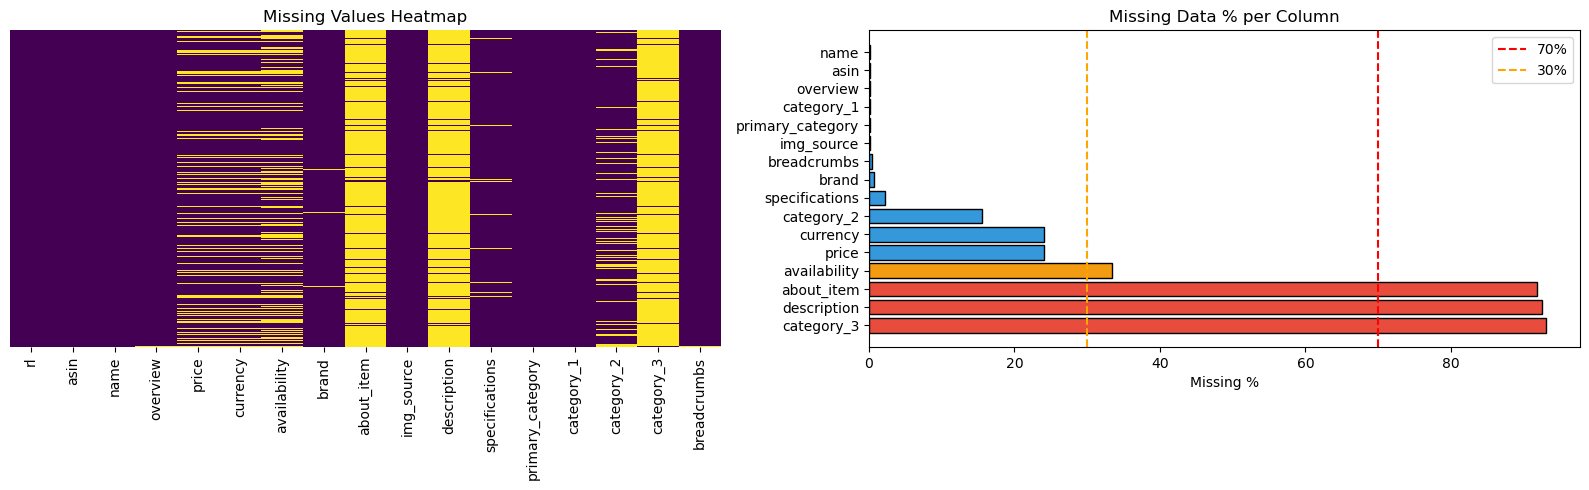

                  Missing Count  Missing Pct
category_3                 1346         93.1
description                1337         92.5
about_item                 1326         91.8
availability                482         33.4
price                       347         24.0
currency                    347         24.0
category_2                  225         15.6
specifications               32          2.2
brand                        10          0.7
breadcrumbs                   6          0.4
img_source                    3          0.2
primary_category              3          0.2
category_1                    3          0.2
overview                      3          0.2
asin                          1          0.1
name                          1          0.1


In [7]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Aquí corregí 'Viridis' por 'viridis' con minúscula
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]

# Dibujar barras solo si hay columnas con valores faltantes
if not mv.empty:
    axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Data % per Column')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No hay valores faltantes', 
                 horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingeniería de Características (Feature Engineering)




<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;"><b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antigüedad y el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías..</div>

In [8]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int) # Esta instruccion imprime laas columnas df enlistadas en este caso Name,
#isbook que hace referecnia al nombre del producto y un boleano si es libro o no.
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total de características generadas: {len(df.columns)}')
print('\nDistribución de los rangos de precios:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


✅ Total de características generadas: 39

Distribución de los rangos de precios:
price_tier
1_budget     104
2_low        285
3_mid        319
4_premium    261
5_luxury     128
Unknown      348


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis univariado 📊 <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Cómo es la distribución de precios? ¿Hay valores atípicos? ¿Los datos están sesgados?
</div>


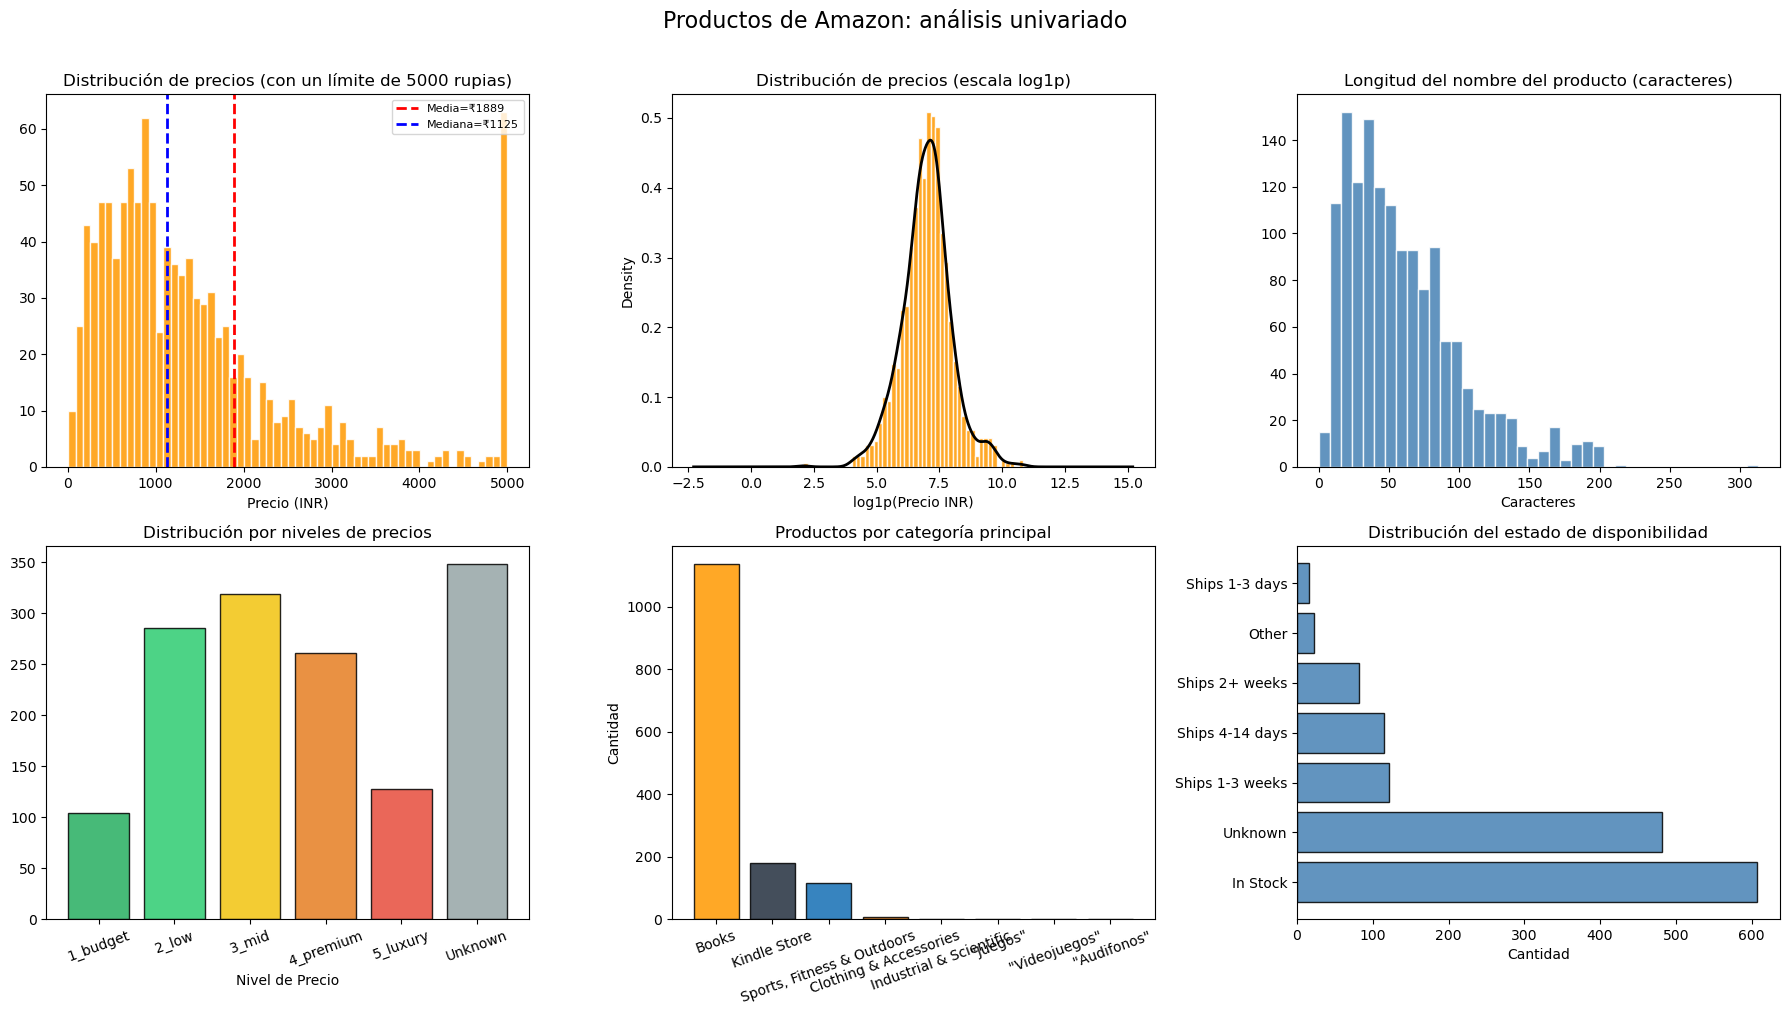

Shapiro-Wilk (precio log, n=500): stat=0.9867, p=0.000158
El precio sigue siendo no normal después de la transformación logarítmica

Estadísticas de precios (INR):
count     1090.00
mean      1888.53
std       3342.12
min          7.00
25%        614.29
50%       1125.00
75%       1853.00
max      50555.00


In [20]:
# ============================================================
# SECCIÓN 4 — Análisis Univariado
# ============================================================
# IMPORTANTE: Añadir esta línea para solucionar el error
import matplotlib.pyplot as plt
from scipy.stats import shapiro

df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Precio original (raw)
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Media=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Mediana=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Distribución de precios (con un límite de 5000 rupias)')
axes[0,0].set_xlabel('Precio (INR)'); axes[0,0].legend(fontsize=8)

# Precio transformado (log)
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Distribución de precios (escala log1p)')
axes[0,1].set_xlabel('log1p(Precio INR)')

# Longitud del nombre
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Longitud del nombre del producto (caracteres)')
axes[0,2].set_xlabel('Caracteres')

# Nivel de precio (Price tier)
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Distribución por niveles de precios')
axes[1,0].set_xlabel('Nivel de Precio'); axes[1,0].tick_params(axis='x', rotation=20)

# Categoría principal
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Productos por categoría principal')
axes[1,1].set_ylabel('Cantidad'); axes[1,1].tick_params(axis='x', rotation=20)

# Disponibilidad
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Distribución del estado de disponibilidad')
axes[1,2].set_xlabel('Cantidad')

plt.suptitle('Productos de Amazon: análisis univariado', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Prueba de normalidad
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (precio log, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'El precio {"distribuye normalmente después de la transformación logarítmica" if p > 0.05 else "sigue siendo no normal después de la transformación logarítmica"}')
print(f'\nEstadísticas de precios (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

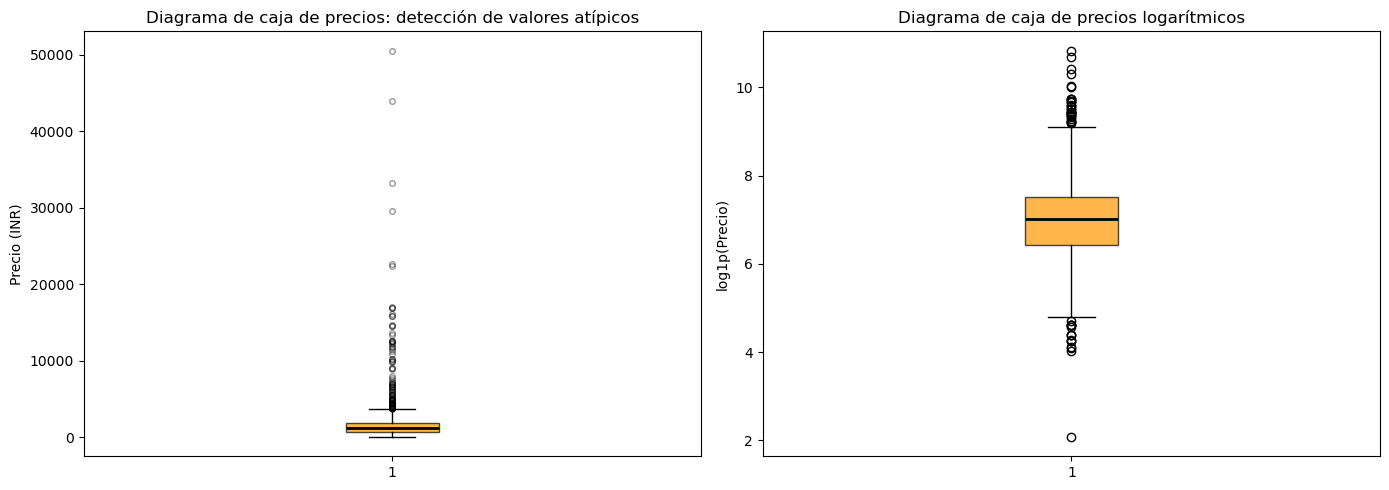

Valores atípicos por método IQR: 94 (8.6%)
Rango de precios (sin valores atípicos): ₹-1244 – ₹3711

Los 10 productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     296

In [19]:
# Análisis de valores atípicos — diagrama de caja (boxplot) e IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Diagrama de caja de precios: detección de valores atípicos')
axes[0].set_ylabel('Precio (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Diagrama de caja de precios logarítmicos')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                     (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'Valores atípicos por método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Rango de precios (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nLos 10 productos más caros:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))


## 6. Análisis de Categorías 🗂️ <a id='s5'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra la mejor relación calidad-precio?

</div>


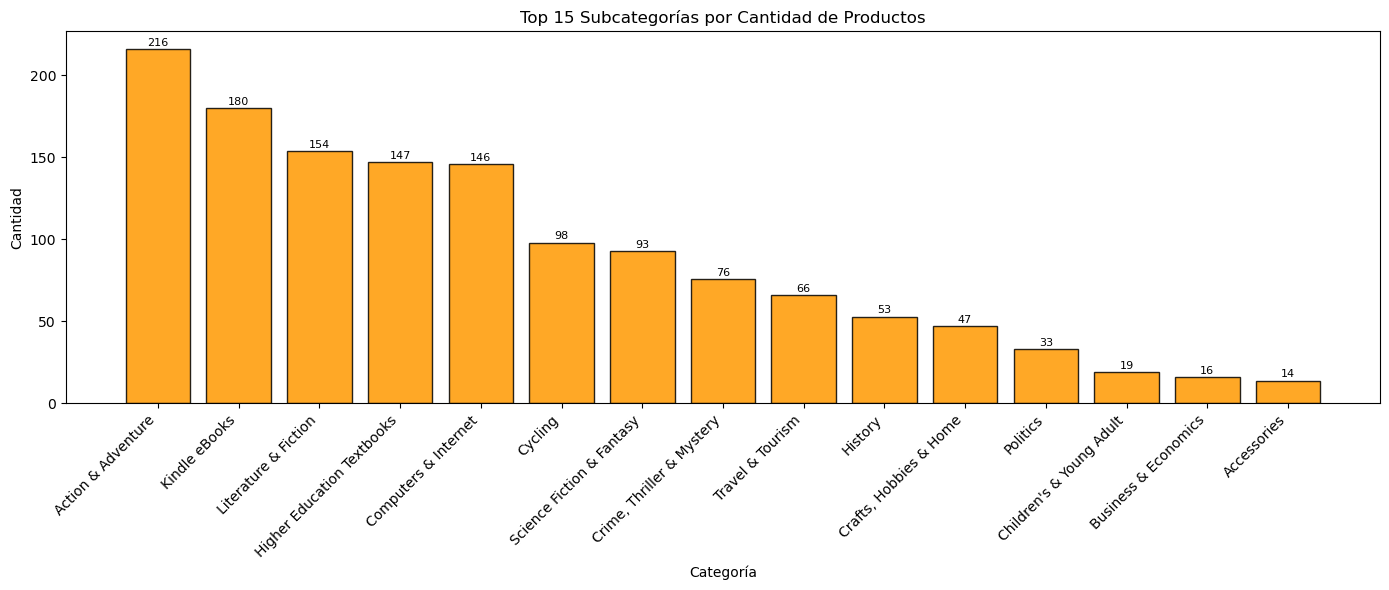

In [22]:
# ============================================================
# SECCIÓN 5 — Análisis de Categorías
# ============================================================
# Las 15 subcategorías principales por cantidad de productos
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)

# Agregar etiquetas de cantidad sobre cada barra
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontsize=8)

plt.title('Top 15 Subcategorías por Cantidad de Productos')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

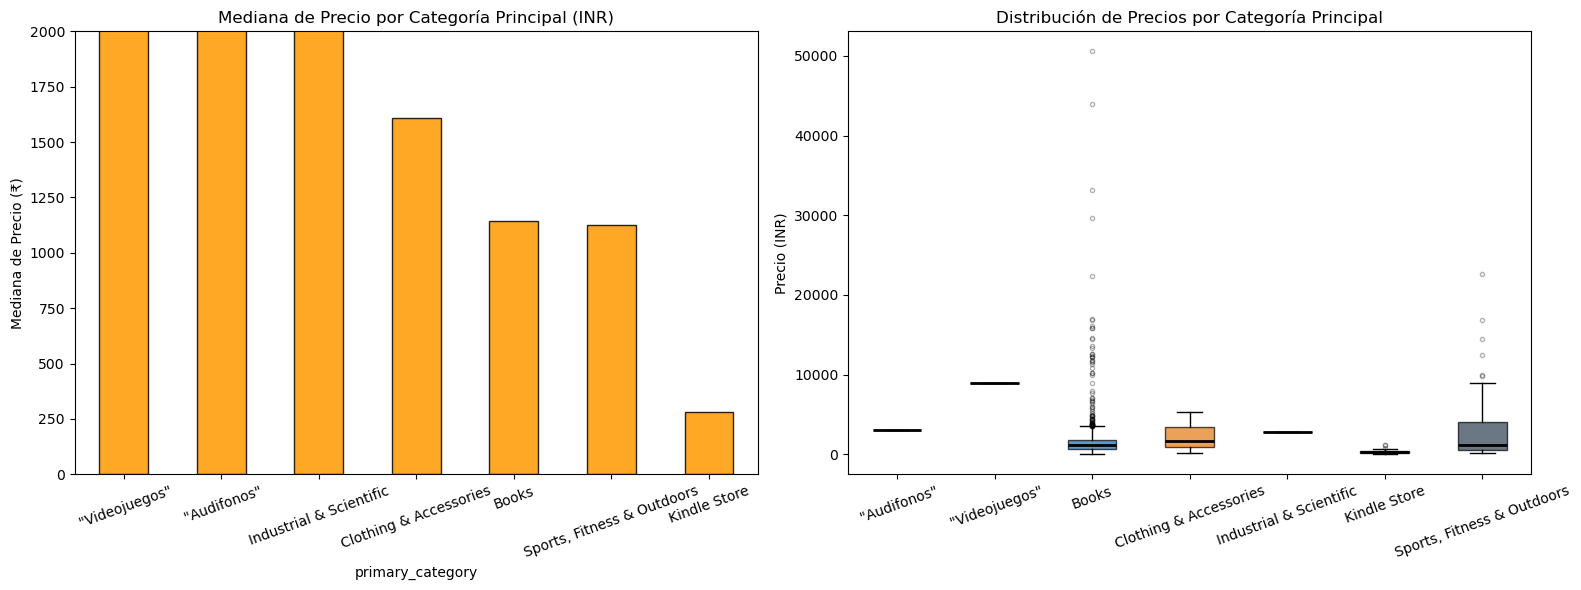

Price stats by primary category:
                              mean  median  count
primary_category                                 
 "Audifonos"                3048.0  3048.0      1
 "Videojuegos"              8999.0  8999.0      1
Books                       1826.2  1145.0    956
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [42]:
# Precio por categoría principal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Mediana de Precio por Categoría Principal (INR)')
axes[0].set_ylabel('Mediana de Precio (₹)')
axes[0].tick_params(axis='x', rotation=20)

# AJUSTE DE ESCALA EXACTO: Fijamos el eje Y de la izquierda de 0 a 2000
axes[0].set_ylim(0, 2000)

# Diagrama de caja (Boxplot)
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]

# SOLUCIÓN AL WARNING: Se cambia 'labels' por 'tick_labels'
bp = axes[1].boxplot(cat_groups, tick_labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

# Se expande la lista a más colores para pintar todas tus categorías y que ninguna quede en blanco
colors_cat = ['#FF9900', '#232F3E', '#146EB4', '#E47911', '#999999', '#8e44ad', '#2c3e50']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# SE MANTIENEN LOS TEXTOS EN INGLÉS PARA LAS ESTADÍSTICAS IMPRESAS
print('Price stats by primary category:')
print(cat_price.to_string())

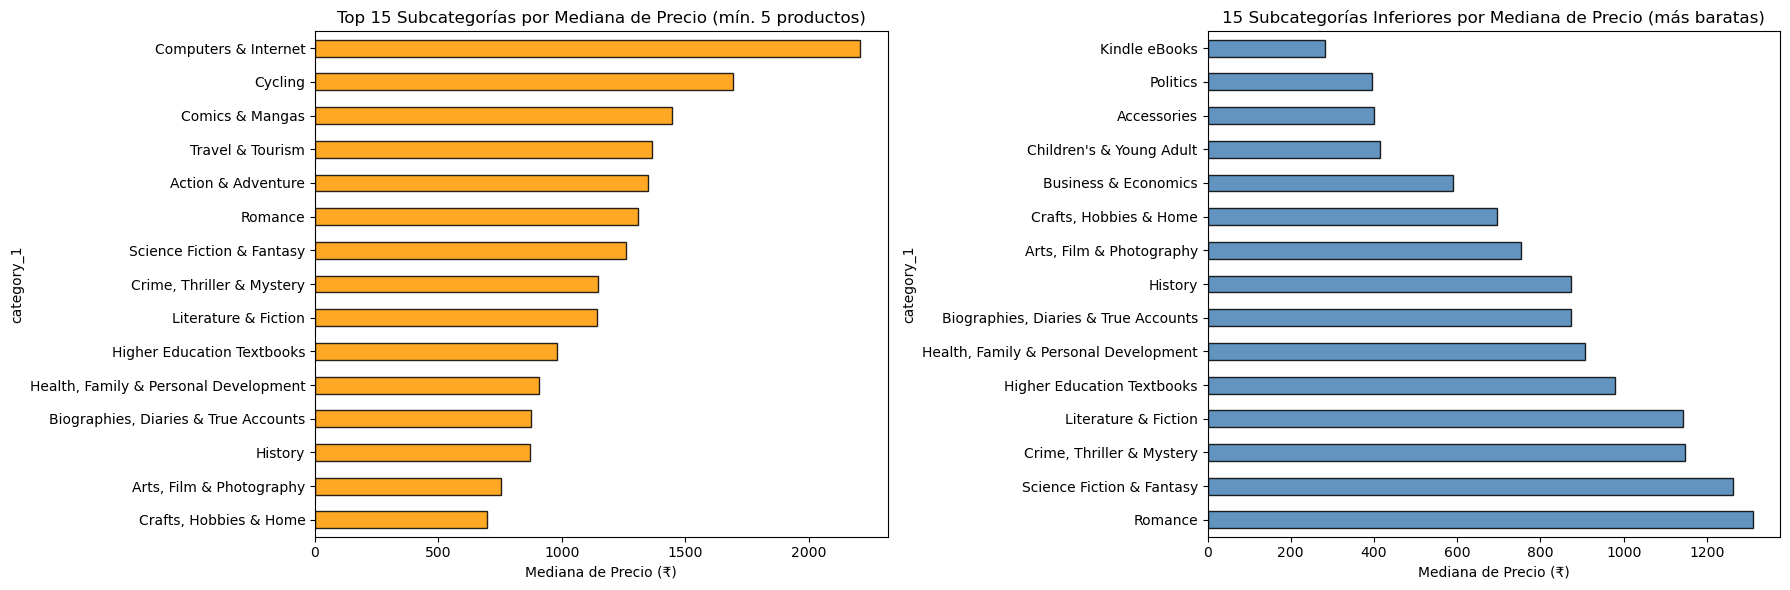

In [26]:
# Las 15 subcategorías principales por mediana de precio
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Subcategorías por Mediana de Precio (mín. 5 productos)')
axes[0].set_xlabel('Mediana de Precio (₹)')

# Las 15 inferiores (más baratas)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('15 Subcategorías Inferiores por Mediana de Precio (más baratas)')
axes[1].set_xlabel('Mediana de Precio (₹)')

plt.tight_layout()
plt.show()

## 7. Análisis de Disponibilidad 📦 <a id='s6'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Key question:</b> Does availability status affect price? Are premium products more likely to be out of stock?
</div>

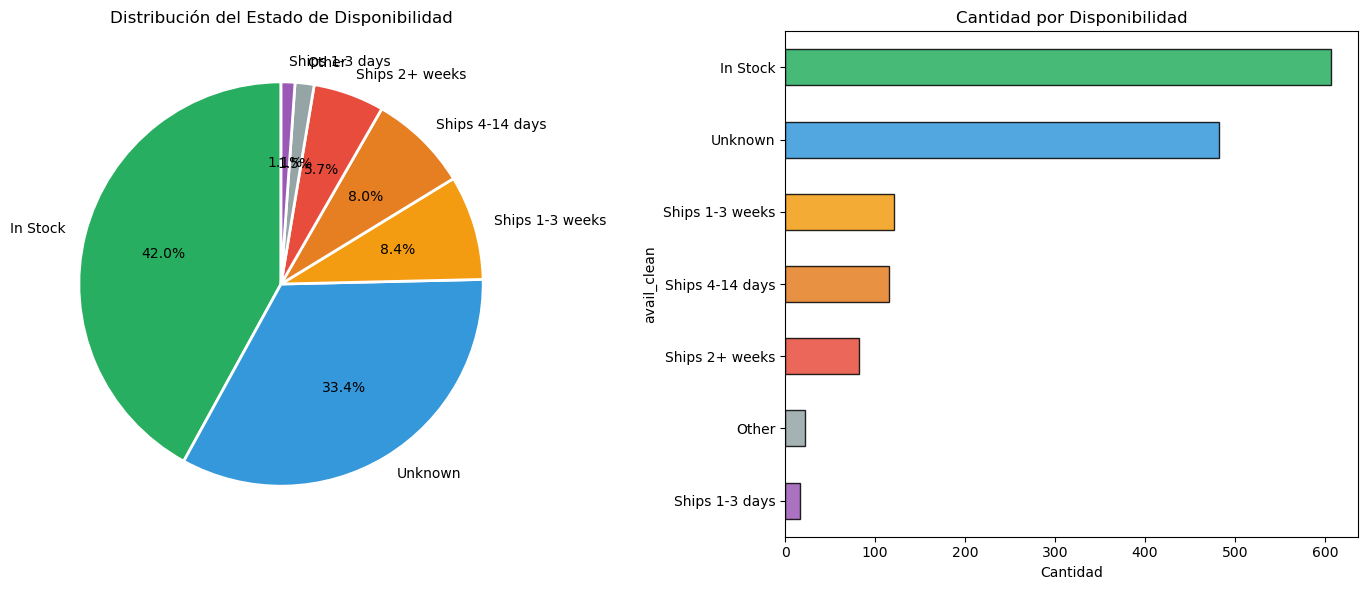

In [28]:
# ============================================================
# SECCIÓN 6 — Análisis de Disponibilidad
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de pastel
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución del Estado de Disponibilidad')

# Gráfico de barras horizontales
avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Cantidad por Disponibilidad')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

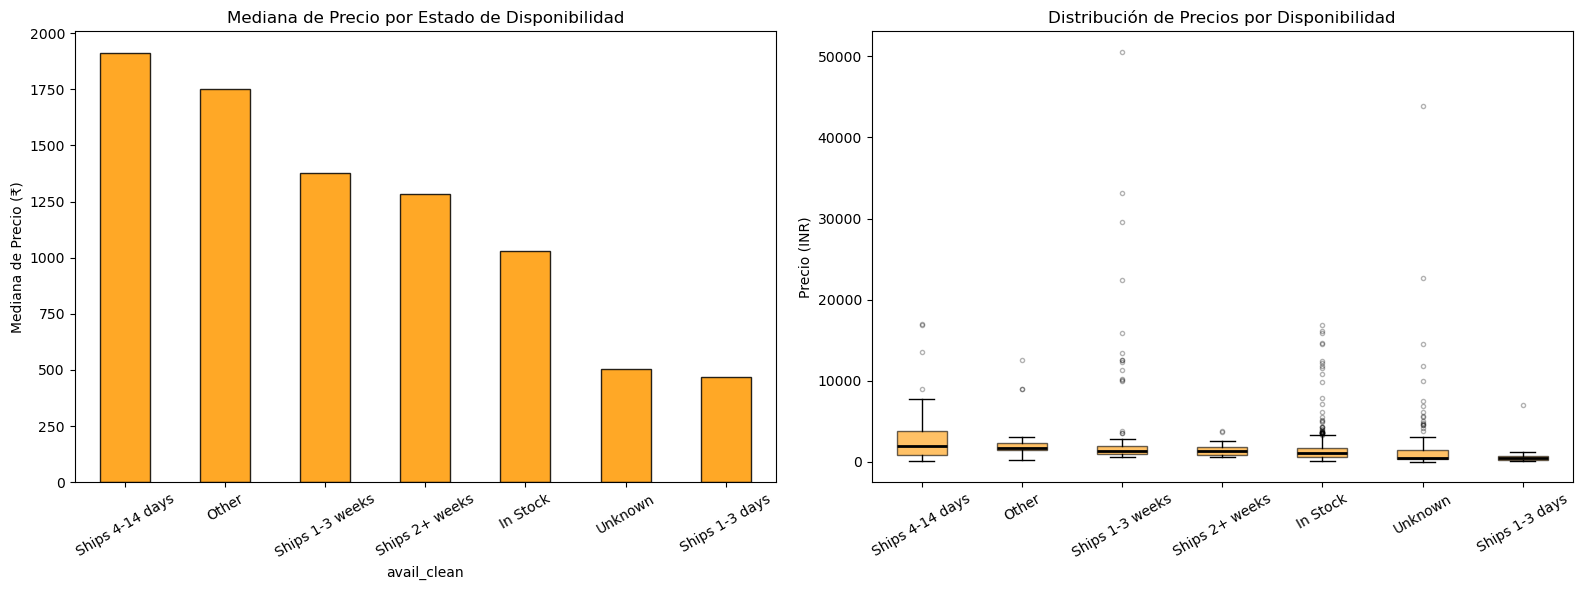

Precio por disponibilidad:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1749.7  2783.4     22
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1284.5  1403.9     82
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [29]:
# Precio por estado de disponibilidad
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras de la mediana
avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Mediana de Precio por Estado de Disponibilidad')
axes[0].set_ylabel('Mediana de Precio (₹)')
axes[0].tick_params(axis='x', rotation=30)

# Diagrama de caja (Boxplot)
avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]

# Se usa tick_labels en lugar de labels para evitar advertencias en Matplotlib
bp = axes[1].boxplot(avail_groups, tick_labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Distribución de Precios por Disponibilidad')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Precio por disponibilidad:')
print(avail_price.to_string())

## 8. Análisis de correlación y bivariado 🔗 <a id='s7'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?

</div>


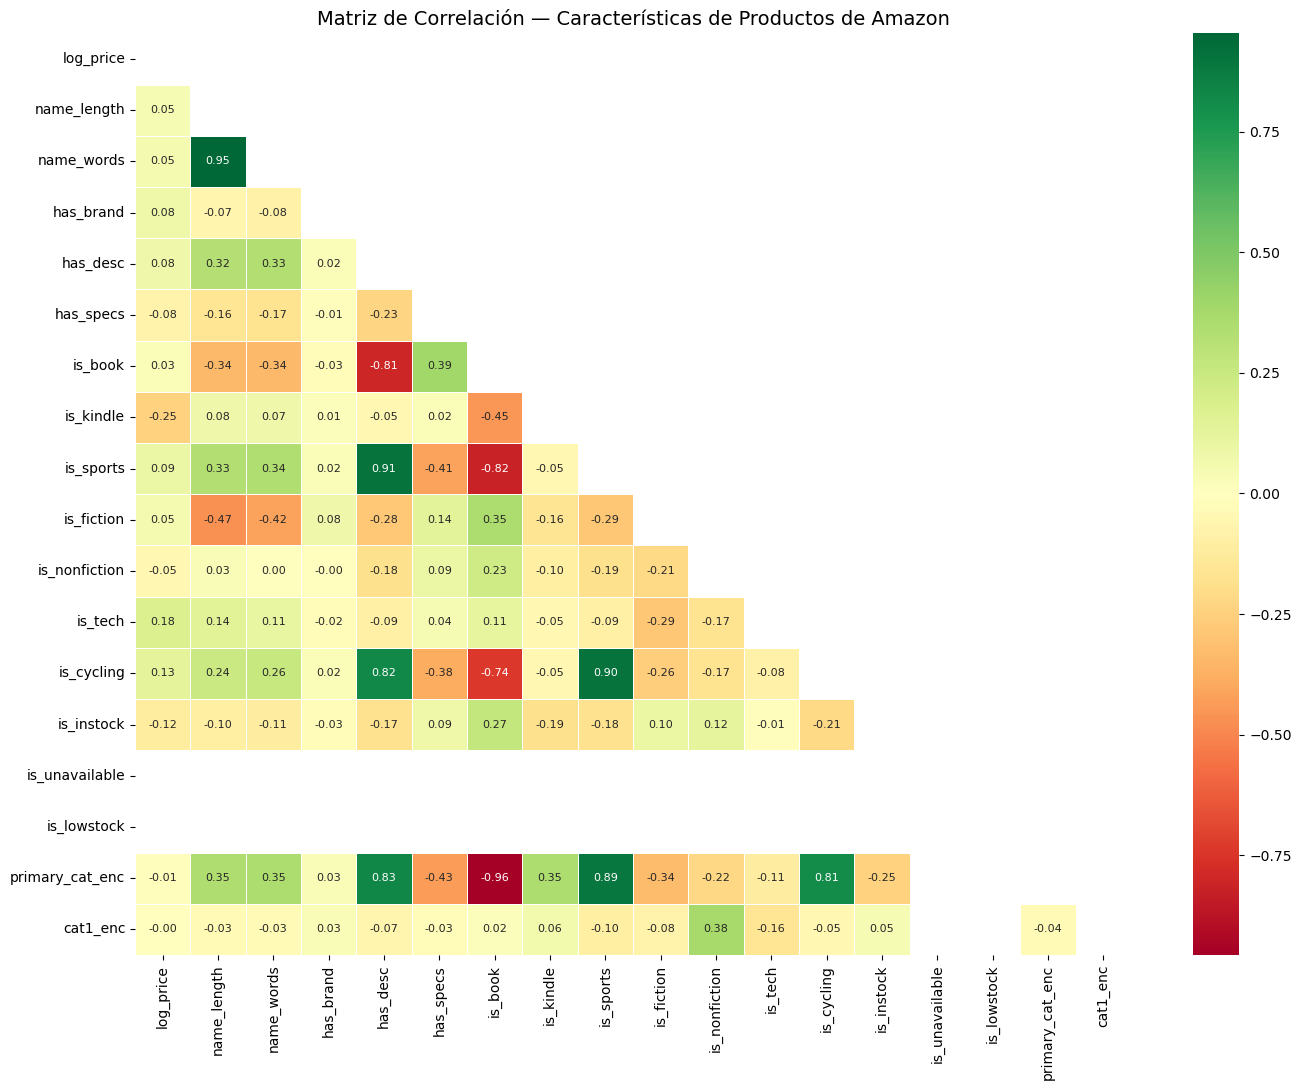

Principales correlaciones con log_price:
is_tech            0.175134
is_cycling         0.125396
is_sports          0.090490
has_brand          0.083832
has_desc           0.079535
name_words         0.053903
is_fiction         0.050811
name_length        0.048835
is_book            0.027143
cat1_enc          -0.003601
primary_cat_enc   -0.014150
is_nonfiction     -0.046414
has_specs         -0.076027
is_instock        -0.117203
is_kindle         -0.246542
is_unavailable          NaN
is_lowstock             NaN


In [30]:
# ============================================================
# SECCIÓN 7 — Análisis de Correlación
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Matriz de Correlación — Características de Productos de Amazon', fontsize=14)
plt.tight_layout()
plt.show()

print('Principales correlaciones con log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

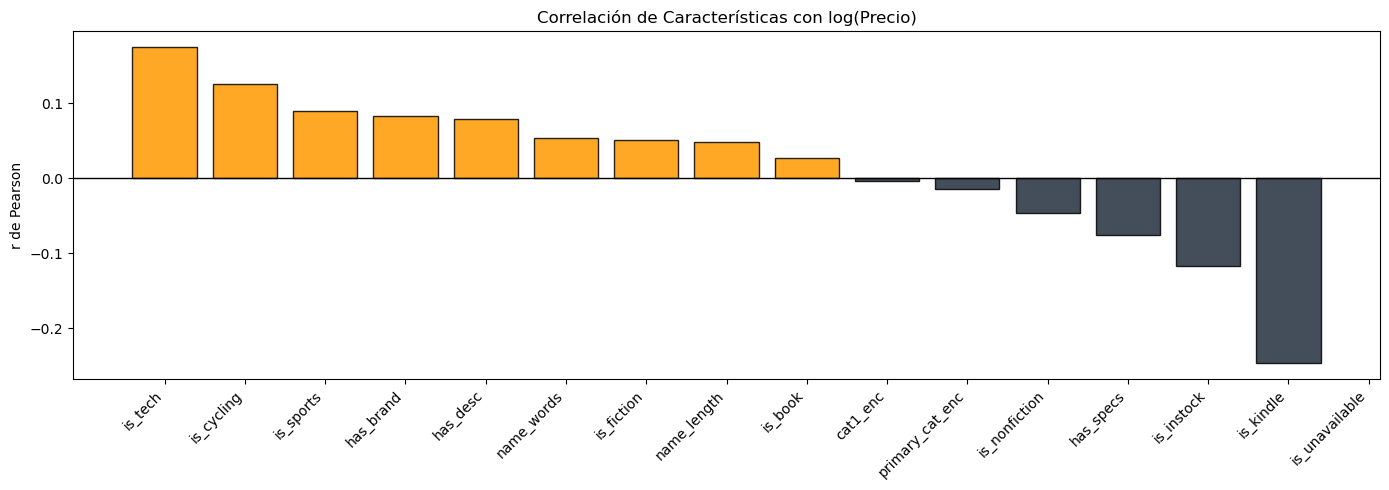

In [31]:
# Gráfico de barras de correlación de características
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Correlación de Características con log(Precio)')
plt.ylabel('r de Pearson')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

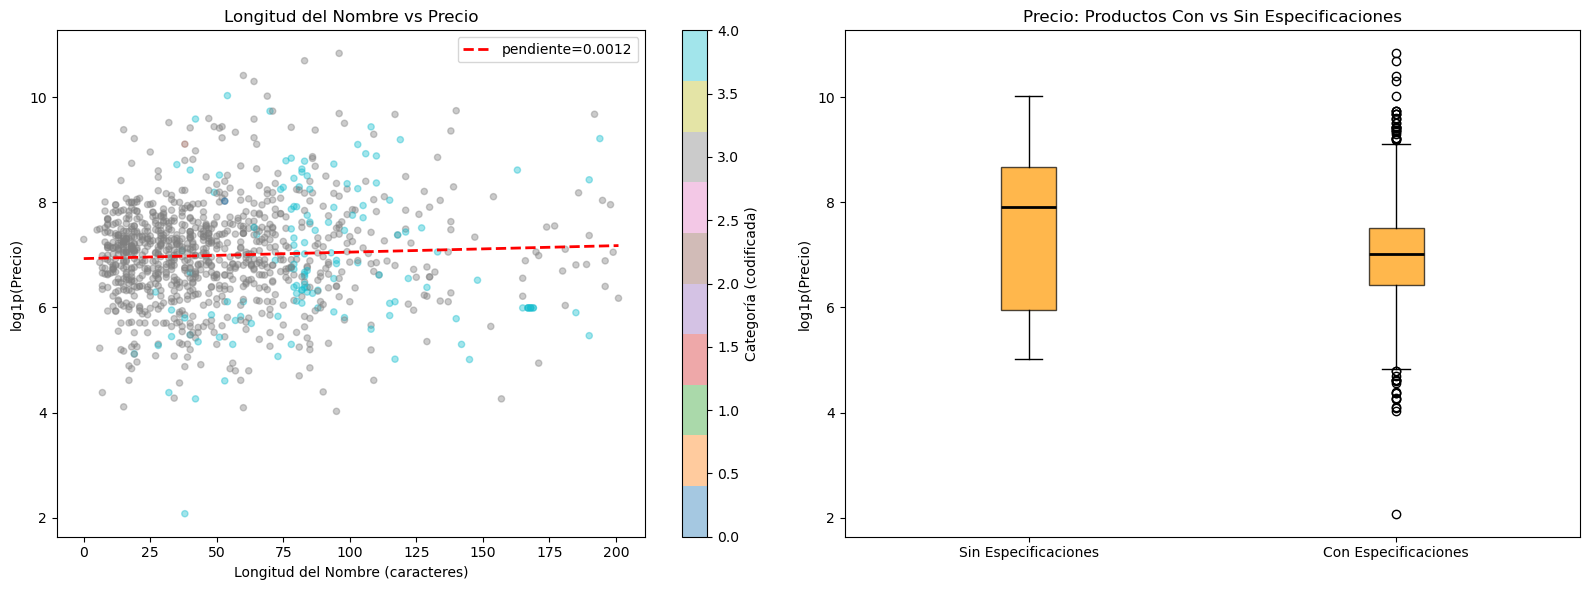

In [34]:
# Gráfico de dispersión (Scatter): longitud del nombre vs precio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Se añaden vmin y vmax para fijar la barra de colores de 0.0 a 4.0
sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20, vmin=0, vmax=4)

plt.colorbar(sc, ax=axes[0], label='Categoría (codificada)')

m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'pendiente={m:.4f}')
axes[0].set_xlabel('Longitud del Nombre (caracteres)')
axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del Nombre vs Precio')
axes[0].legend()

# Precio según si tiene especificaciones (has_specs)
# SOLUCIÓN AL WARNING: Se cambió 'labels' por 'tick_labels'
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                tick_labels=['Sin Especificaciones', 'Con Especificaciones'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Precio: Productos Con vs Sin Especificaciones')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()